In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Literal

from hcc_multimodal.baselines.config import MODELS_LR, MODELS_RF
from hcc_multimodal.baselines.data import add_rfs_columns, get_hcc_genes
from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    DeseqCPMSelector,
    apply_selector_before_cv,
)
from sklearn.feature_selection import SelectKBest, f_classif

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RNA_COUNT_FILTER: int | None = None
RNA_COUNT_FILTER_MIN_SAMPLES: int | None = None
DESEQ_PVALUE = 0.05
DESEQ_MIN_FEATURES = 20
RFS_YEARS = [1, 2]
CV_N_FOLDS = 3

SELECTOR: Literal["deseq", "sklearn_kbest"] = "deseq"
KBEST: int = 80
SELECTOR_BEFORE_CV: bool = True
PREDEFINED_GENES: bool = False

OUTPUT_DIR_NAME: str = "deseq_p0.05_before_cv_all_genes"

# Read data

In [4]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

rna_data = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

In [5]:
columns = rna_data["Gene Symbol"]
rna_data = rna_data.T.iloc[2:, :]
rna_data.columns = columns.values

# Drop columns with NaN gene symbols and deduplicate gene names
rna_data = rna_data.loc[:, ~pd.isnull(rna_data.columns)]
rna_data = rna_data.loc[:, ~rna_data.columns.duplicated()]

# Convert expression values to numeric, make SID an integer column
rna_data = rna_data.apply(pd.to_numeric, errors="coerce")
rna_data.index = rna_data.index.astype(int)
rna_data = rna_data.rename_axis("SID").reset_index()

print(f"RNA data shape (patients × genes): {rna_data.shape}")
rna_data.head()

RNA data shape (patients × genes): (60, 50987)


,SID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
0,39,0,0,0,0,0,0,245,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,150,0,153,0,0,0,828,63,0,...,0,0,0,0,0,0,0,0,0,0
3,33,139,0,0,0,0,0,3206,0,224,...,0,0,0,0,0,1,0,3,0,0
4,132,0,0,0,0,37,2,985,0,236,...,0,0,0,0,0,1,0,0,0,0


# RFS column

In [6]:
clinical_data = add_rfs_columns(clinical_data)
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].head(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
0,31.791781,0.0,0.0,0.0
1,30.279452,1.0,0.0,0.0
2,40.865753,1.0,0.0,0.0
3,14.301370,1.0,0.0,1.0
4,24.756164,1.0,0.0,0.0
5,9.600000,1.0,1.0,1.0
6,8.054795,1.0,1.0,1.0
7,6.936986,1.0,1.0,1.0
8,49.643836,1.0,0.0,0.0
9,11.441096,1.0,1.0,1.0


In [7]:
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].tail(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
59,52.734247,0.0,0.0,0.0
60,63.813699,1.0,0.0,0.0
61,75.879452,0.0,0.0,0.0
62,2.367123,0.0,NaN,NaN
63,7.791781,1.0,1.0,1.0
64,5.983562,1.0,1.0,1.0
65,5.786301,1.0,1.0,1.0
66,132.526027,1.0,0.0,0.0
67,27.320548,1.0,0.0,0.0
68,97.347945,0.0,0.0,0.0


In [8]:
print(clinical_data["rfs_1year"].value_counts(dropna=False))
print(clinical_data["rfs_2year"].value_counts(dropna=False))

rfs_1year
0.0    43
1.0    21
NaN     5
Name: count, dtype: int64
rfs_2year
0.0    33
1.0    29
NaN     7
Name: count, dtype: int64


In [9]:
rna_count = rna_data.drop(columns=["SID"])
rna_count.index = rna_data["SID"]
print("Before filtering:", rna_count.shape[1])

rna_count_flt = rna_count
if RNA_COUNT_FILTER is not None and RNA_COUNT_FILTER_MIN_SAMPLES is not None:
    rna_count_flt = rna_count_flt.loc[
        :,
        (rna_count_flt >= RNA_COUNT_FILTER).sum(axis=0) >= RNA_COUNT_FILTER_MIN_SAMPLES,
    ]
    print("After count filtering:", rna_count_flt.shape[1])

if PREDEFINED_GENES:
    hcc_genes = get_hcc_genes()
    rna_count_flt = rna_count_flt.loc[:, rna_count_flt.columns.intersection(hcc_genes)]
    print("After predefined gene filtering:", rna_count_flt.shape[1])

rna_count_flt.head()

Before filtering: 50986


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
66,150,0,153,0,0,0,828,63,0,82,...,0,0,0,0,0,0,0,0,0,0
33,139,0,0,0,0,0,3206,0,224,0,...,0,0,0,0,0,1,0,3,0,0
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,1,0,0,0,0


In [10]:
rna_rfs = rna_count_flt.merge(
    clinical_data[["SID", "rfs_1year", "rfs_2year"]], on="SID"
)
rna_rfs = rna_rfs.set_index("SID").sort_index()
rna_rfs.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1,rfs_1year,rfs_2year
SID,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,4,0,0,0.0,0.0
3,1718,0,1130,0,0,0,39477,524,1149,1099,...,0,0,0,0,0,0,0,0,0.0,0.0
4,0,0,0,0,0,0,342,0,47,0,...,0,0,0,2,0,2,0,0,0.0,1.0
5,0,0,0,64,0,0,172,0,95,0,...,0,0,0,0,0,0,0,0,0.0,0.0
6,0,0,0,0,0,1,228,0,4,0,...,0,0,0,0,0,1,0,0,1.0,1.0


# CV experiments

In [11]:
if SELECTOR == "deseq":
    selector = DeseqCPMSelector(pvalue=DESEQ_PVALUE, min_features=DESEQ_MIN_FEATURES)
elif SELECTOR == "sklearn_kbest":
    selector = SelectKBest(f_classif, k=KBEST)
else:
    raise ValueError(f"Unknown SELECTOR: {SELECTOR!r}")

In [12]:
OUTPUT_DIR = ROOT / "reports" / "0504" / OUTPUT_DIR_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /Users/amo/programData/hcc-multimodal/reports/0504/deseq_p0.05_before_cv_all_genes


Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.02 seconds.



Fitting dispersions...


... done in 1.49 seconds.

Fitting dispersion trend curve...


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.28 seconds.

Fitting MAP dispersions...


...

... done in 0.57 seconds.

Fitting LFCs...


... done in 0.92 seconds.



Running Wald tests...


... done in 0.73 seconds.

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/base.py:910: UserWarning: DeseqCPMSelector: only 6 gene(s) passed padj<0.05; falling back to top 20 by padj.
  return self.fit(X, y, **fit_params).transform(X)


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       210.966424       -0.184960  1.413280 -0.130873  0.895876   
TNMD          19.485663        1.254629  1.985275  0.631967  0.527408   
DPM1         194.163960       -0.048657  1.334414 -0.036464  0.970913   
SCYL3        167.367426        0.306809  1.234320  0.248566  0.803697   
C1orf112      98.444930        0.048992  1.455350  0.033663  0.973146   
...                 ...             ...       ...       ...       ...   
AC003043.2     1.634930       -1.442566  1.390783 -1.037233  0.299627   
AC135068.11    1.126608        1.550716  2.848184  0.544458  0.586126   
AL356417.3    16.054488       -2.359453  1.026188 -2.299240  0.021491   
AC104389.6     0.038862       -0.123393  3.209088 -0.038451  0.969328   
AP000646.1     0.000000        0.000000  0.000000  0.000000       NaN   

                 padj  
TSPAN6       0.999995  
TNMD         0.99999

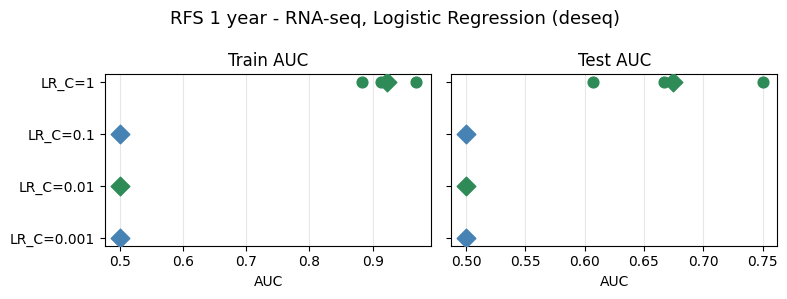

[RFS 1 year - RNA-seq]  n=56  positives=19  features=20


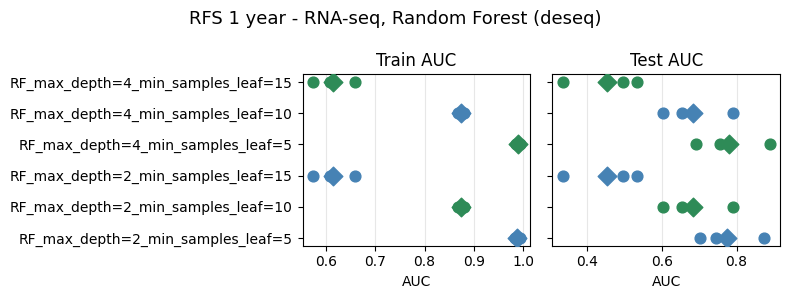

/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 1.44 seconds.

Fitting dispersion trend curve...


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.28 seconds.

Fitting MAP dispersions...


...

... done in 0.43 seconds.

Fitting LFCs...


... done in 0.72 seconds.



Running Wald tests...


... done in 0.73 seconds.

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/base.py:910: UserWarning: DeseqCPMSelector: only 3 gene(s) passed padj<0.05; falling back to top 20 by padj.
  return self.fit(X, y, **fit_params).transform(X)


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       210.977458       -0.825635  1.414003 -0.583899  0.559288   
TNMD          29.371480        0.430522  1.857437  0.231783  0.816707   
DPM1         196.474521       -0.353054  1.338852 -0.263699  0.792012   
SCYL3        174.043340       -0.051822  1.199737 -0.043195  0.965546   
C1orf112     101.960002       -0.252070  1.369402 -0.184073  0.853956   
...                 ...             ...       ...       ...       ...   
AC003043.2     0.457649       -0.226790  1.254712 -0.180750  0.856564   
AC135068.11    3.929069        2.930442  2.149668  1.363206  0.172817   
AL356417.3     3.328129        0.057699  0.844483  0.068325  0.945527   
AC104389.6     0.041225       -0.363888  3.053434 -0.119173  0.905138   
AP000646.1     0.000000        0.000000  0.000000  0.000000       NaN   

                 padj  
TSPAN6       0.999959  
TNMD         0.99995

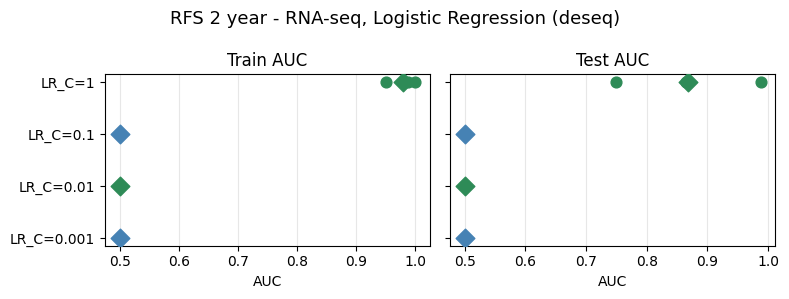

[RFS 2 year - RNA-seq]  n=54  positives=26  features=20


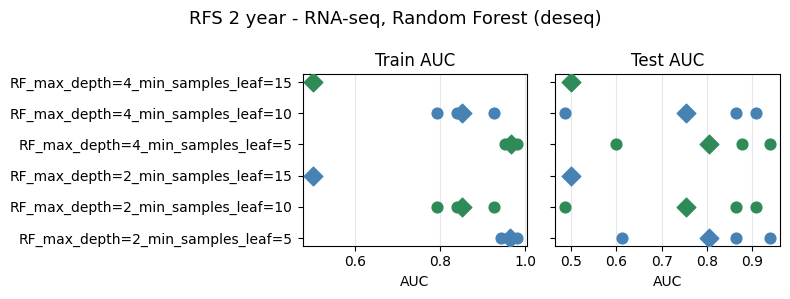

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RFS 1 year - RNA-seq,LR_C=0.001,0.500,0.000,0.661,0.022
1,RFS 1 year - RNA-seq,LR_C=0.01,0.500,0.000,0.661,0.022
2,RFS 1 year - RNA-seq,LR_C=0.1,0.500,0.000,0.661,0.022
3,RFS 1 year - RNA-seq,LR_C=1,0.675,0.059,0.627,0.080
4,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=5,0.774,0.074,0.750,0.029
5,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=10,0.683,0.080,0.661,0.022
6,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=15,0.453,0.086,0.661,0.022
7,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=5,0.779,0.083,0.767,0.053
8,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=10,0.683,0.080,0.661,0.022
9,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=15,0.453,0.086,0.661,0.022


In [13]:
X = rna_rfs.drop(columns=["rfs_1year", "rfs_2year"])
x_columns = {col: DataType.CONTINUOUS for col in X}

selector_first = SELECTOR == "deseq"
rna_cpm = SELECTOR == "sklearn_kbest"

all_records = []
all_fold_records = []

for RFS_YEAR in RFS_YEARS:
    y = rna_rfs[f"rfs_{RFS_YEAR}year"]
    EXPERIMENT_LABEL = f"RFS {RFS_YEAR} year - RNA-seq"

    if SELECTOR_BEFORE_CV:
        X_cv, y_cv, x_columns_cv, cv_kwargs = apply_selector_before_cv(
            X, y, x_columns, selector,
            selector_first=selector_first, rna_cpm=rna_cpm,
            label=EXPERIMENT_LABEL,
            save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_preselected_features.csv",
        )
    else:
        X_cv, y_cv, x_columns_cv = X, y, x_columns
        cv_kwargs = dict(
            feature_selector=selector,
            selector_first=selector_first,
            rna_cpm=rna_cpm,
        )

    records_lr, fold_records_lr = run_cv_experiment(
        X_cv, y_cv, x_columns_cv, EXPERIMENT_LABEL,
        models=MODELS_LR, n_splits=CV_N_FOLDS,
        **cv_kwargs,
    )
    plot_cv_results(
        fold_records_lr,
        title=f"{EXPERIMENT_LABEL}, Logistic Regression ({SELECTOR})",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_lr.png",
    )

    records_rf, fold_records_rf = run_cv_experiment(
        X_cv, y_cv, x_columns_cv, EXPERIMENT_LABEL,
        models=MODELS_RF, n_splits=CV_N_FOLDS,
        **cv_kwargs,
    )
    plot_cv_results(
        fold_records_rf,
        title=f"{EXPERIMENT_LABEL}, Random Forest ({SELECTOR})",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_rf.png",
    )

    # Save selected features and non-zero LR coefficients (all folds combined)
    for fold_records, model_type in [(fold_records_lr, "lr"), (fold_records_rf, "rf")]:
        feats = []
        for _, row in fold_records.iterrows():
            if row["selected_features"] is not None:
                df = row["selected_features"].copy()
                df["fold"] = row["fold"]
                df["model"] = row["model"]
                feats.append(df)
        if feats:
            (
                pd.concat(feats, ignore_index=True).to_csv(
                    OUTPUT_DIR / f"rfs_{RFS_YEAR}y_{model_type}_selected_features.csv",
                    index=False,
                )
            )

        nonzero = []
        for _, row in fold_records.iterrows():
            if row["lr_nonzero_features"] is not None:
                df = row["lr_nonzero_features"].copy()
                df["fold"] = row["fold"]
                df["model"] = row["model"]
                nonzero.append(df)
        if nonzero:
            pd.concat(nonzero, ignore_index=True).to_csv(
                OUTPUT_DIR / f"rfs_{RFS_YEAR}y_{model_type}_lr_nonzero_features.csv",
                index=False,
            )

        fold_records_to_save = fold_records.drop(
            columns=["selected_features", "lr_nonzero_features"], errors="ignore"
        ).copy()
        fold_records_to_save["rfs_year"] = RFS_YEAR
        fold_records_to_save["model_type"] = model_type
        all_fold_records.append(fold_records_to_save)

    all_records.extend([records_lr, records_rf])

summary = pd.concat(all_records, ignore_index=True)
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
pd.concat(all_fold_records, ignore_index=True).to_csv(
    OUTPUT_DIR / "fold_records.csv", index=False
)
display(summary)